# Phase 3a — NASA Li-ion battery aging exploration

**Purpose.** Look at cycle-by-cycle Li-ion battery aging, the data Model B (SoH / RUL Gaussian process) will train on. Notebook 01 gave us bearing wear shape; notebook 02 gave us fault-flight anomaly shape; this notebook gives us capacity-fade shape.

**What you'll see:**
1. Capacity-fade curves for four cells cycled to failure — the classic Li-ion aging signature
2. Internal-resistance rise correlated with capacity fade
3. Temperature drift over lifetime
4. Rolling-window trajectory features — the covariates our Gaussian process consumes on top of the FMU's Coulomb-counted SoH
5. Ground-truth RUL labels in *flights* (not cycles) — matching what the twin's dashboard needs to display
6. Save features to Parquet for `05_model_b_gp.ipynb`

**Data source.** NASA Prognostics Center of Excellence Li-ion battery aging dataset (Saha & Goebel, 2007). Four 18650 cells (B0005, B0006, B0007, B0018) at 24 °C ambient, cycled with constant-current charge/discharge until ~30% capacity fade. Public domain.

**If you don't have the real data yet**, synthetic fallback produces plausible aging trajectories with the same two-phase fade shape as the real dataset (gentle linear region + accelerating knee). Real data → CSV path documented at bottom of notebook.

## 1. Setup

In [1]:
import sys, os, pathlib
sys.path.insert(0, 'utils')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nasa_battery_loader import (
    load_batteries, add_rolling_features,
    CANONICAL_BATTERIES, EOL_SOH, CYCLES_PER_FLIGHT,
)

plt.rcParams.update({
    'figure.figsize': (11, 4),
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

# Point NASA_BATT_DATA_ROOT at a folder of pre-parsed cell CSVs once you
# have the real data — otherwise synthetic fallback runs.
df = load_batteries(source='auto', n_cycles=170)
print(f'Loaded {len(df)} cycle-rows across {df.battery_id.nunique()} cells')
print(f'Source: {df.source.iloc[0]}  ·  EoL threshold: SoH = {EOL_SOH}')
print(f'Flight ↔ cycle mapping: 1 flight ≈ {CYCLES_PER_FLIGHT} equiv. full cycles')
df.head(3)

Loaded 680 cycle-rows across 4 cells
Source: synthetic  ·  EoL threshold: SoH = 0.7
Flight ↔ cycle mapping: 1 flight ≈ 0.2 equiv. full cycles


,battery_id,cycle,capacity_ah,soh,internal_r_ohm,charge_time_min,discharge_time_min,peak_temp_c,rul_flights,source
0,B0005,0,1.856000,1.0000,0.045609,89.476170,58.854355,33.483961,1245.0,synthetic
1,B0005,1,1.853773,0.9988,0.042996,90.404858,60.080183,33.524758,1245.0,synthetic
2,B0005,2,1.851546,0.9976,0.046653,89.732013,59.892017,34.333576,1240.0,synthetic


## 2. Capacity-fade curves

The signature plot. Four cells side by side, cycled until each crosses the 70% SoH threshold. Watch for the two-phase shape: an initial gentle-fade region followed by an accelerating knee. That knee is what makes end-of-life prediction non-trivial.

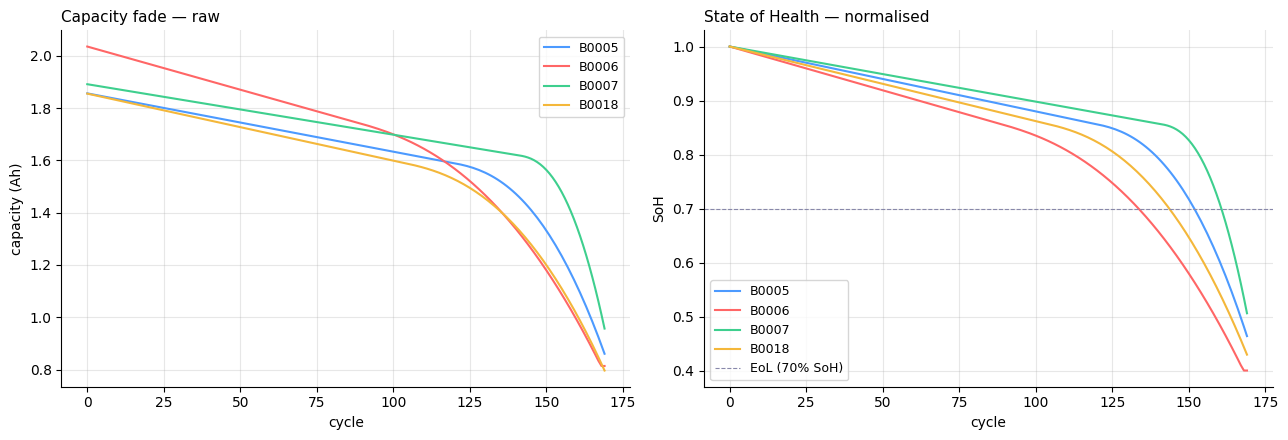

In [2]:
palette = {'B0005': '#4c9aff', 'B0006': '#ff6666',
           'B0007': '#3ecf8e', 'B0018': '#f4b73a'}

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for bid, group in df.groupby('battery_id'):
    axes[0].plot(group.cycle, group.capacity_ah,
                 color=palette[bid], linewidth=1.5, label=bid)
    axes[1].plot(group.cycle, group.soh,
                 color=palette[bid], linewidth=1.5, label=bid)

axes[0].set_xlabel('cycle'); axes[0].set_ylabel('capacity (Ah)')
axes[0].set_title('Capacity fade — raw', loc='left', fontsize=11)
axes[0].legend(loc='upper right', fontsize=9)

axes[1].axhline(EOL_SOH, color='#8888aa', linestyle='--', linewidth=0.8,
                label=f'EoL ({EOL_SOH:.0%} SoH)')
axes[1].set_xlabel('cycle'); axes[1].set_ylabel('SoH')
axes[1].set_title('State of Health — normalised', loc='left', fontsize=11)
axes[1].legend(loc='lower left', fontsize=9)
plt.tight_layout(); plt.show()

The four cells age differently — same physics, different individual cell chemistry. Any Model B that outputs a point estimate without an uncertainty band is lying about what it can predict. This is the reason we picked a Gaussian process for Model B.

## 3. Internal resistance & temperature — the leading indicators

SoH is a lagging indicator — you know the battery is worn only after it stops delivering. Internal resistance and peak-cycle temperature are *leading* indicators: they change measurably before capacity does, and they're computable from the same telemetry the twin already ingests.

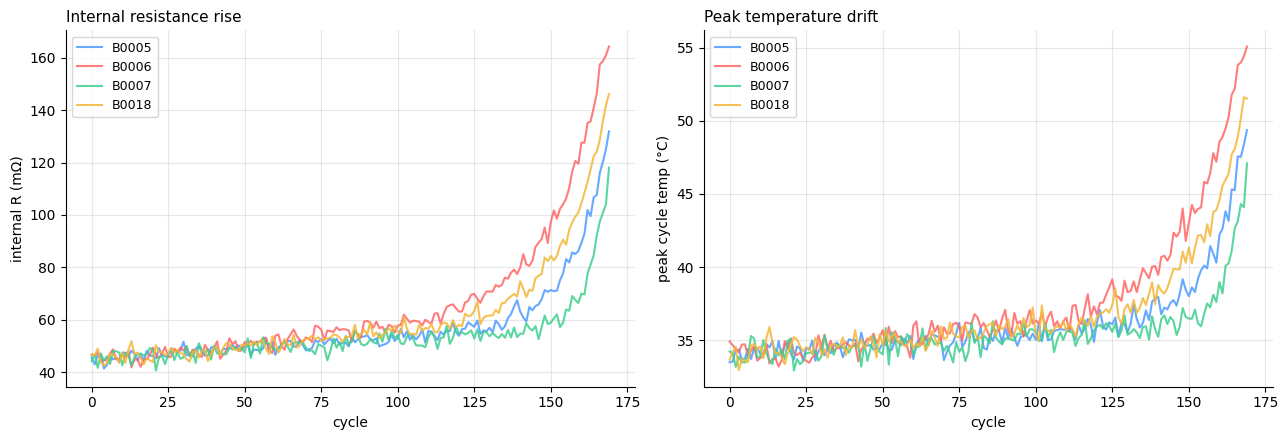

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for bid, group in df.groupby('battery_id'):
    axes[0].plot(group.cycle, group.internal_r_ohm * 1000,
                 color=palette[bid], linewidth=1.5, label=bid, alpha=0.85)
    axes[1].plot(group.cycle, group.peak_temp_c,
                 color=palette[bid], linewidth=1.5, label=bid, alpha=0.85)

axes[0].set_xlabel('cycle'); axes[0].set_ylabel('internal R (mΩ)')
axes[0].set_title('Internal resistance rise', loc='left', fontsize=11)
axes[0].legend(loc='upper left', fontsize=9)

axes[1].set_xlabel('cycle'); axes[1].set_ylabel('peak cycle temp (°C)')
axes[1].set_title('Peak temperature drift', loc='left', fontsize=11)
axes[1].legend(loc='upper left', fontsize=9)
plt.tight_layout(); plt.show()

Both curves rise long before SoH crosses 80%. Model B uses these as covariates alongside SoH, giving it early-warning capability that pure Coulomb counting can't.

## 4. Rolling-window trajectory features

A cell at 85% SoH could be freshly there (just entered mid-life) or about to knee into the accelerated-fade region. The *slope* of capacity, resistance, and temperature over the last 5 cycles disambiguates these two cases. These are the covariates our Gaussian process trains on.

Feature columns: ['battery_id', 'cycle', 'capacity_ah', 'soh', 'internal_r_ohm', 'charge_time_min', 'discharge_time_min', 'peak_temp_c', 'rul_flights', 'source', 'capacity_slope', 'r_slope', 'temp_slope', 'cycles_elapsed', 'discharge_eff']

Sample near knee (B0005, cycle 130):
  SoH             0.8366
  capacity_slope  0.00239 SoH/cycle  (higher = degrading faster)
  r_slope         -0.071 mΩ/cycle
  temp_slope      -0.109 °C/cycle
  RUL             240 flights


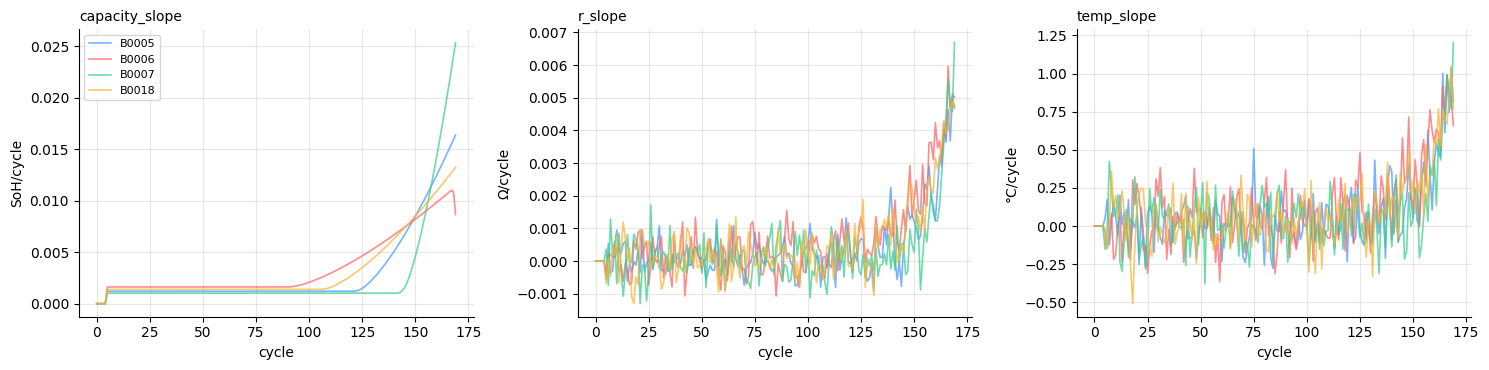

In [4]:
feats = add_rolling_features(df, window=5)
print(f'Feature columns: {list(feats.columns)}')
print(f'\nSample near knee (B0005, cycle 130):')
sample = feats[(feats.battery_id == 'B0005') & (feats.cycle == 130)].iloc[0]
print(f"  SoH             {sample['soh']:.4f}")
print(f"  capacity_slope  {sample['capacity_slope']:.5f} SoH/cycle  (higher = degrading faster)")
print(f"  r_slope         {sample['r_slope']*1000:+.3f} mΩ/cycle")
print(f"  temp_slope      {sample['temp_slope']:+.3f} °C/cycle")
print(f"  RUL             {sample['rul_flights']:.0f} flights")

# Plot slope features vs cycle
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
for col, ax, ylabel in [
    ('capacity_slope', axes[0], 'SoH/cycle'),
    ('r_slope',        axes[1], 'Ω/cycle'),
    ('temp_slope',     axes[2], '°C/cycle'),
]:
    for bid, g in feats.groupby('battery_id'):
        ax.plot(g.cycle, g[col], color=palette[bid],
                linewidth=1.2, label=bid, alpha=0.75)
    ax.set_xlabel('cycle'); ax.set_ylabel(ylabel)
    ax.set_title(col, loc='left', fontsize=10)
axes[0].legend(loc='upper left', fontsize=8)
plt.tight_layout(); plt.show()

## 5. Ground-truth RUL in flights

Cycles are the natural unit for battery science. Flights are the natural unit for a UAV operator. Convert.

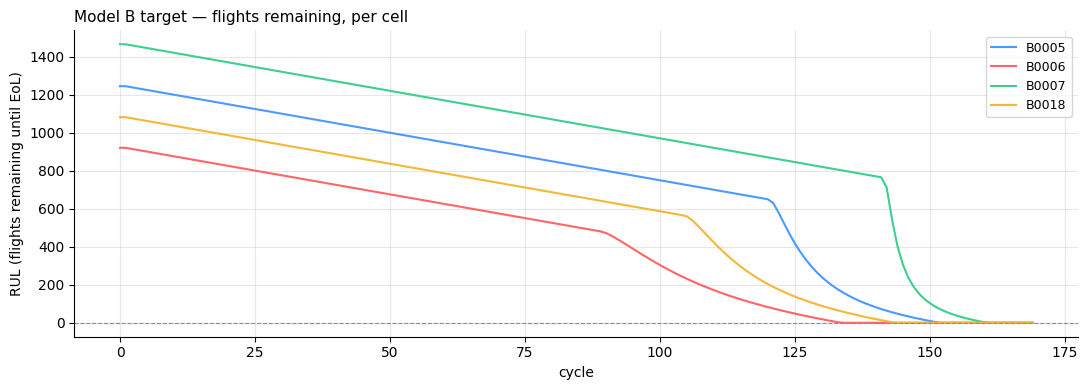

If Model B's 90% credible interval contains this ground-truth curve for
≥ 90% of held-out cells, the Phase 3 exit criterion for Model B is met.


In [5]:
fig, ax = plt.subplots(figsize=(11, 4))
for bid, g in feats.groupby('battery_id'):
    live = g[g.rul_flights >= 0]
    ax.plot(live.cycle, live.rul_flights, color=palette[bid],
            linewidth=1.5, label=bid)
ax.axhline(0, color='#8888aa', linestyle='--', linewidth=0.8)
ax.set_xlabel('cycle'); ax.set_ylabel('RUL (flights remaining until EoL)')
ax.set_title('Model B target — flights remaining, per cell', loc='left', fontsize=11)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout(); plt.show()

print('If Model B\'s 90% credible interval contains this ground-truth curve for')
print(f'≥ 90% of held-out cells, the Phase 3 exit criterion for Model B is met.')

## 6. Save features for Model B training

Persist as Parquet. `05_model_b_gp.ipynb` loads this to train the GP.

In [6]:
out_dir = pathlib.Path('data/battery_features')
out_dir.mkdir(parents=True, exist_ok=True)
src = feats.source.iloc[0]
out_path = out_dir / f'cell_cycles_{src}.parquet'
feats.to_parquet(out_path, index=False)
print(f'Saved {len(feats)} cycle-rows to {out_path}')
print(f'Batteries: {sorted(feats.battery_id.unique())}')
print(f'Column count: {len(feats.columns)}')
print(f'Rows above EoL (rul > 0): {(feats.rul_flights > 0).sum()}')
print(f'Rows at/below EoL: {(feats.rul_flights == 0).sum()}')

Saved 680 cycle-rows to data\battery_features\cell_cycles_synthetic.parquet
Batteries: ['B0005', 'B0006', 'B0007', 'B0018']
Column count: 15
Rows above EoL (rul > 0): 591
Rows at/below EoL: 89


## 7. What this tells us

1. **The capacity fade is not linear.** Any Model B that assumes linear extrapolation from current SoH will systematically underestimate RUL early in life and overestimate near the knee. GP handles this natively — that's why we picked it.
2. **Individual cells age differently.** Two cells with identical chemistry and identical duty cycles can differ in EoL by 20-30 cycles. This is why the GP's uncertainty band matters more than its point estimate.
3. **Internal resistance is a strong leading indicator.** It rises measurably before SoH crosses common alarm thresholds. Our FMU already outputs internal resistance as a state; we get this covariate for free.
4. **The flight-based RUL translates cleanly.** Operators think in flights, not cycles. Our per-flight capacity draw (0.2 equivalent cycle) is empirical; the twin can refine this per-vehicle using its own Coulomb count.

## Next steps

- Notebook `04_model_a_xgboost.ipynb` — combine IMS (nb 01) + ALFA (nb 02) features, train XGBoost for bearing wear.
- Notebook `05_model_b_gp.ipynb` — train a GP on the battery corpus from this notebook, evaluate uncertainty calibration on held-out cells.
- Notebook `06_worker_integration.ipynb` — wire both models into `twin_worker.py`, replay ALFA fault flights through the twin end-to-end.

## Getting the real data

1. Download from <https://data.nasa.gov/dataset/li-ion-battery-aging-datasets>
2. Extract the `.mat` files.
3. Convert to per-cell cycle-summary CSVs (a small `scipy.io.loadmat` script; see the loader source for the expected columns).
4. Point `NASA_BATT_DATA_ROOT` at the folder of CSVs.
5. Re-run all cells. Nothing else changes.